<a name="top" id="top"></a>

<div align="center">
    <h1>Stochastic Optimization</h1>
    <a href="https://github.com/sa1K">Sai Karthik</a>
    <br>
    <i>Weldon School of Biomedical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/parkyr">Yirang Park</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://github.com/bernalde">David E. Bernal Neira</a>
    <br>
    <i>Davidson School of Chemical Engineering, Purdue University</i>
    <br>
    <br>
    <a href="https://colab.research.google.com/github/SECQUOIA/Pharma-optimization-flowsheet/blob/main/Enhanced_model/Pharma_Optimizer.ipynb" target="_parent">
        <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
    </a>
    <a href="https://secquoia.github.io/">
        <img src="https://img.shields.io/badge/🌲⚛️🌐-SECQUOIA-blue" alt="SECQUOIA"/>
    </a>
</div>

# Introduction

This notebook extends the deterministic model to handle **demand uncertainty** using two-stage stochastic programming.

## Two-Stage Stochastic Programming Framework

**First Stage (Here-and-Now Decisions):**
- Vendor selection at each manufacturing step: $x_{s,v}$
- Transport route selection: $y_{route}$

**Second Stage (Wait-and-See Decisions):**
- Unmet demand (shortage) per scenario: $u_{\omega}$

**Objective:** Minimize expected total cost across all demand scenarios:
$$\min \sum_{\omega \in \Omega} p_\omega \left[ \text{Production Cost} + \text{Transport Cost} + \text{Penalty} \cdot u_\omega \right]$$

# Setup and Imports

In [45]:
# Check if running in Google Colab
try:
    import google.colab
    IN_COLAB = True
except:
    IN_COLAB = False

# Install dependencies if in Colab
if IN_COLAB:
    !pip install -q pyomo
    !apt-get install -y -qq glpk-utils
    !pip install highspy
    !sudo apt-get install graphviz graphviz-dev
    !pip install networkx

In [46]:
import pyomo.environ as pyo
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Import from our package
from pharma_optimizer import (
    Generator,
    DemandScenarioGenerator,
    StochasticProductionOptimizer,
    visualize_solution_from_optimizer
)

# Data Generation

Generate random manufacturing and transportation data.

In [47]:
# Generate a 3-step, 3-vendor instance
generator = Generator(steps=3, options=3)
generator.createManufacturingData()
generator.createTransportData()

# Display data
prod_df = pd.read_csv("manufacturingData2.csv")
print("Production Data:")
print(prod_df)

Production Data:
   step Vendor  Production   Cost
0     1      A        4196  85142
1     1      B        2627  23016
2     1      C       42815   2554
3     2      A         225  12676
4     2      B       73340  84423
5     2      C       98396  35048
6     3      A       28061  37598
7     3      B       12052  29565
8     3      C       82782  63491


# Demand Scenario Generation

The `DemandScenarioGenerator` class creates demand scenarios using:
1. **Discrete scenarios**: Low/Base/High demand levels with specified probabilities
2. **Truncated Normal**: Sampled scenarios from a truncated normal distribution

## Demand Scaling Rationale

The mean demand must be set carefully relative to the vendor capacities in the data, otherwise all scenario results will be identical.

**Why results collapse to the same value:**

In this two-stage stochastic model, production and transport costs are **first-stage (fixed)** decisions — they are the same across all scenarios. The only scenario-dependent cost term is the **shortage penalty** (`penalty × unmet_demand`). If unmet demand is zero in every scenario, all total costs are equal.

There are two ways unmet demand stays zero even as demand increases:
1. All scenario demands are below the bottleneck capacity of the selected vendors.
2. The optimizer switches to higher-capacity vendors to avoid the shortage penalty — which it will always do when the penalty is large enough.

**The hard ceiling:** The maximum achievable bottleneck across *all* vendor combinations is constrained by the tightest step. In this dataset:

| Step | Best Vendor | Capacity |
|------|-------------|----------|
| 1    | C           | 97,240   |
| 2    | C           | 66,539   | ← binding constraint |
| 3    | C           | 77,239   |

No combination of vendors can sustain throughput above **66,539 units**.

**Fix:** Set `mean_demand = 55,000` so the high scenario demand (`1.3 × 55,000 = 71,500`) exceeds this ceiling. The optimizer *cannot* avoid a shortage in the high scenario regardless of vendor choice, forcing nonzero shortage costs and differentiating the scenario results.

In [48]:
# Create scenario generator with mean demand = 55000, CV = 20%
# Max achievable bottleneck across ALL vendor combinations is 66,539 (Step 2, Vendor C).
# High scenario (1.3x = 71,500) exceeds this, guaranteeing a shortage regardless of vendor choice.
scenario_gen = DemandScenarioGenerator(mean_demand=55000, cv=0.2, seed=42)

# Generate discrete Low/Base/High scenarios
discrete_scenarios = scenario_gen.generate_discrete_scenarios(
    levels=[0.8, 1.0, 1.3],
    probabilities=[0.2, 0.5, 0.3]
)

print("Discrete Scenarios:")
scenario_gen.summary(discrete_scenarios)

Discrete Scenarios:
=== DEMAND SCENARIOS ===
Scenario              Demand  Probability
----------------------------------------
low                 44000.00       20.00%
base                55000.00       50.00%
high                71500.00       30.00%
----------------------------------------
Expected demand: 57750.00
Std deviation:   9915.27
CV:              17.17%


In [49]:
# Generate scenarios from truncated normal distribution
normal_scenarios = scenario_gen.generate_normal_scenarios(num_scenarios=5)

print("\nTruncated Normal Scenarios:")
scenario_gen.summary(normal_scenarios)


Truncated Normal Scenarios:
=== DEMAND SCENARIOS ===
Scenario              Demand  Probability
----------------------------------------
scenario_1          40902.99       20.00%
scenario_2          49231.62       20.00%
scenario_3          55000.01       20.00%
scenario_4          60768.42       20.00%
scenario_5          69097.07       20.00%
----------------------------------------
Expected demand: 55000.02
Std deviation:   9633.30
CV:              17.52%


# Stochastic Optimization

Run the two-stage stochastic optimization with demand uncertainty.

In [50]:
# Create stochastic optimizer with discrete scenarios
stochastic_optimizer = StochasticProductionOptimizer(
    prod_cost_csv="manufacturingData2.csv",
    transport_cost_csv="transportData2.csv",
    scenarios=discrete_scenarios,
    shortage_penalty=1000.0
)

# Solve
result = stochastic_optimizer.solve(solver_name='glpk')
print(f"Solver status: {result.solver.termination_condition}\n")

# Display results
stochastic_optimizer.summary()

Solver status: optimal

STATIC-DYNAMIC STOCHASTIC OPTIMIZATION RESULTS
(Multi-Echelon with Demand Uncertainty)

--- FIRST-STAGE DECISIONS (Static) ---

Selected vendors by step:
  Step 1: C (Cost: $2,554, Capacity: 42,815)
  Step 2: C (Cost: $35,048, Capacity: 98,396)
  Step 3: C (Cost: $63,491, Capacity: 82,782)

Selected transport routes:

Optimal Path: Step 1(C) -> Step 2(C) -> Step 3(C)

--- MULTI-ECHELON THROUGHPUT ---
Per-step capacity of selected vendors:
  Step 1: 42,815 <-- BOTTLENECK
  Step 2: 98,396
  Step 3: 82,782

Effective throughput (bottleneck): 42,815

--- SECOND-STAGE RESULTS (Dynamic per Scenario) ---
scenario    demand  probability  bottleneck_capacity  throughput  unmet_demand  prod_cost  transport_cost  shortage_cost    total_cost
     low 44,000.00         0.20            42,815.00   42,815.00      1,185.00 101,093.00            0.00   1,185,000.00  1,286,093.00
    base 55,000.00         0.50            42,815.00   42,815.00     12,185.00 101,093.00            

# Visualization

Visualize the optimal vendor selection path.

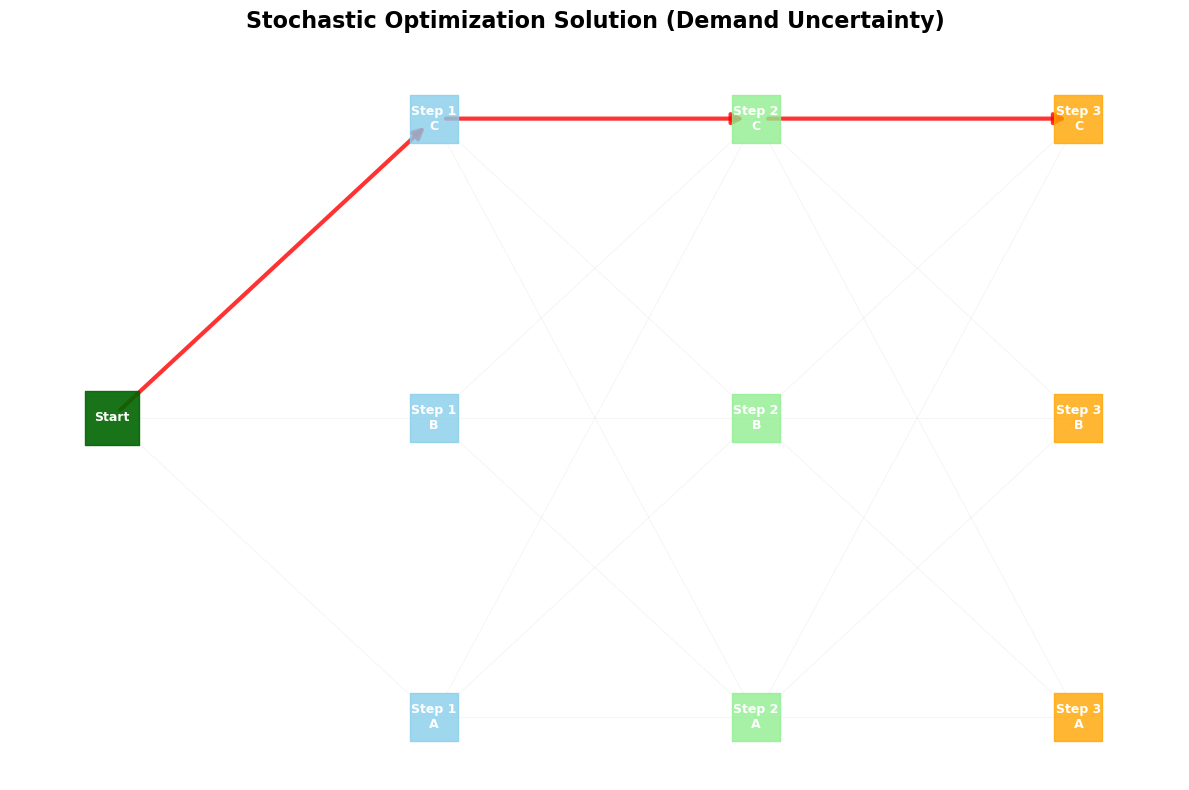

In [51]:
# Visualize the stochastic solution
G, pos, chosen_path = visualize_solution_from_optimizer(
    stochastic_optimizer,
    title="Stochastic Optimization Solution (Demand Uncertainty)"
)
plt.show()

# Scenario Analysis

Detailed analysis of results across different demand scenarios.

In [52]:
# Get detailed scenario results
scenario_df = stochastic_optimizer.get_scenario_results()
print("Scenario Results:")
print(scenario_df.to_string(index=False))

# Cost statistics
stats = stochastic_optimizer.get_cost_statistics()
print(f"\nExpected Cost: ${stats['expected_cost']:,.2f}")
print(f"Std Deviation: ${stats['std_dev']:,.2f}")
print(f"Cost Range: ${stats['min_cost']:,.2f} - ${stats['max_cost']:,.2f}")

Scenario Results:
scenario  demand  probability  bottleneck_capacity  throughput  unmet_demand  prod_cost  transport_cost  shortage_cost  total_cost
     low 44000.0          0.2              42815.0     42815.0        1185.0   101093.0             0.0      1185000.0   1286093.0
    base 55000.0          0.5              42815.0     42815.0       12185.0   101093.0             0.0     12185000.0  12286093.0
    high 71500.0          0.3              42815.0     42815.0       28685.0   101093.0             0.0     28685000.0  28786093.0

Expected Cost: $15,036,093.00
Std Deviation: $9,915,266.01
Cost Range: $1,286,093.00 - $28,786,093.00


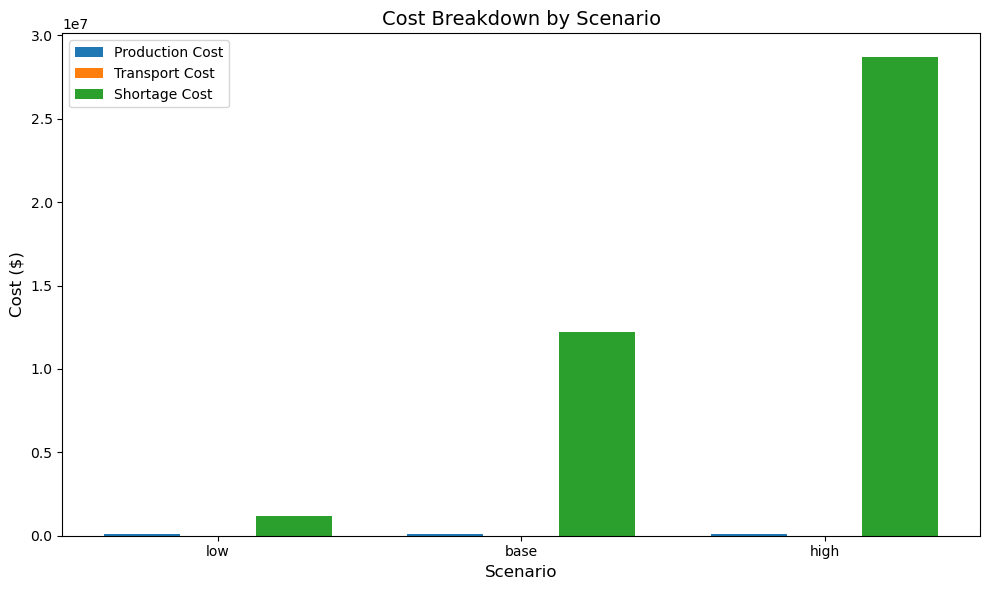

In [53]:
# Visualize cost breakdown by scenario
fig, ax = plt.subplots(figsize=(10, 6))

scenarios = scenario_df['scenario'].tolist()
x = np.arange(len(scenarios))
width = 0.25

ax.bar(x - width, scenario_df['prod_cost'], width, label='Production Cost')
ax.bar(x, scenario_df['transport_cost'], width, label='Transport Cost')
ax.bar(x + width, scenario_df['shortage_cost'], width, label='Shortage Cost')

ax.set_xlabel('Scenario', fontsize=12)
ax.set_ylabel('Cost ($)', fontsize=12)
ax.set_title('Cost Breakdown by Scenario', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(scenarios)
ax.legend()
plt.tight_layout()
plt.show()

# Comparison: Discrete vs. Normal Scenarios

In [54]:
# Run with normal scenarios
stochastic_normal = StochasticProductionOptimizer(
    prod_cost_csv="manufacturingData2.csv",
    transport_cost_csv="transportData2.csv",
    scenarios=normal_scenarios,
    shortage_penalty=1000.0
)

result = stochastic_normal.solve(solver_name='glpk')

print("=" * 60)
print("COMPARISON: Discrete vs Normal Scenarios")
print("=" * 60)

discrete_stats = stochastic_optimizer.get_cost_statistics()
normal_stats = stochastic_normal.get_cost_statistics()

print(f"\nDiscrete Scenarios (3 scenarios):")
print(f"  Expected Cost: ${discrete_stats['expected_cost']:,.2f}")
print(f"  Std Dev:       ${discrete_stats['std_dev']:,.2f}")

print(f"\nNormal Scenarios (5 scenarios):")
print(f"  Expected Cost: ${normal_stats['expected_cost']:,.2f}")
print(f"  Std Dev:       ${normal_stats['std_dev']:,.2f}")

COMPARISON: Discrete vs Normal Scenarios

Discrete Scenarios (3 scenarios):
  Expected Cost: $15,036,093.00
  Std Dev:       $9,915,266.01

Normal Scenarios (5 scenarios):
  Expected Cost: $12,668,516.96
  Std Dev:       $9,088,666.87


# Sensitivity Analysis: Shortage Penalty

Penalty $100: Expected Cost = $1,594,593.00
Penalty $500: Expected Cost = $7,568,593.00
Penalty $1,000: Expected Cost = $15,036,093.00
Penalty $2,000: Expected Cost = $29,971,093.00
Penalty $5,000: Expected Cost = $74,776,093.00


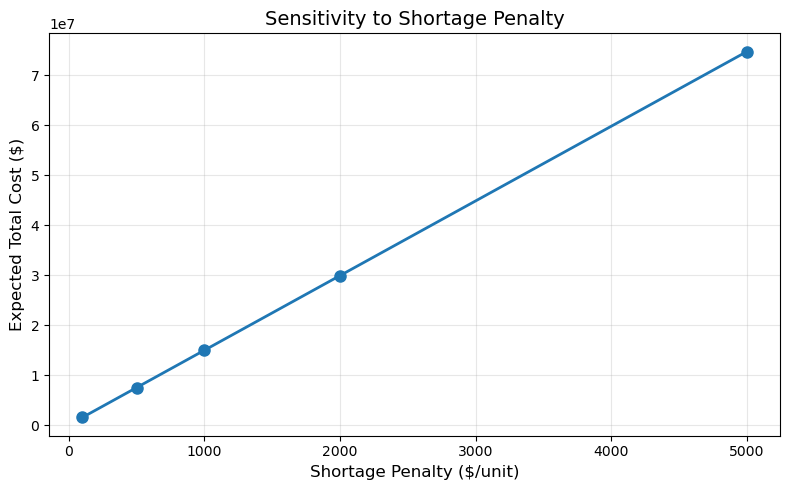

In [55]:
# Test different shortage penalty values
penalties = [100, 500, 1000, 2000, 5000]
expected_costs = []

for penalty in penalties:
    optimizer = StochasticProductionOptimizer(
        prod_cost_csv="manufacturingData2.csv",
        transport_cost_csv="transportData2.csv",
        scenarios=discrete_scenarios,
        shortage_penalty=penalty
    )
    optimizer.solve(solver_name='glpk')
    expected_costs.append(optimizer.get_expected_cost())
    print(f"Penalty ${penalty:,}: Expected Cost = ${optimizer.get_expected_cost():,.2f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(penalties, expected_costs, 'o-', linewidth=2, markersize=8)
ax.set_xlabel('Shortage Penalty ($/unit)', fontsize=12)
ax.set_ylabel('Expected Total Cost ($)', fontsize=12)
ax.set_title('Sensitivity to Shortage Penalty', fontsize=14)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()